In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

- Check basic info:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


- let's check the total rows and column into dataset:

In [6]:
print("Total numbers of rows and columns in the dataset:", df.shape)

Total numbers of rows and columns in the dataset: (1200, 13)


In [7]:
print(df.dtypes)

age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [8]:
# Missing Values into dataset:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

- Basic cleaning if needed.

In [10]:
df['gender'] = df['gender'].astype('category')
df['platform_usage'] = df['platform_usage'].astype('category')
df['social_interaction_level'] = df['social_interaction_level'].astype('category')

In [11]:
# Check target variable
print("\nDepression Label Distribution:\n", df['depression_label'].value_counts())


Depression Label Distribution:
 depression_label
0    1169
1      31
Name: count, dtype: int64


- Summery Statistics:

In [12]:
print("\n=== Summary Statistics ===")
print(df.describe())


=== Summary Statistics ===
               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.200000   
50%      16.000000                  4.500000     6.500000   
75%      18.000000                  6.300000     7.600000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count               1200.000000           1200.000000        1200.000000   
mean                   1.740333              2.990383           1.014500   
std                    0.716660              0.576758           0.582185   
min                    0.500000              2.000000           0.000000   
25%                    1.100000           

- Chart Visualization:

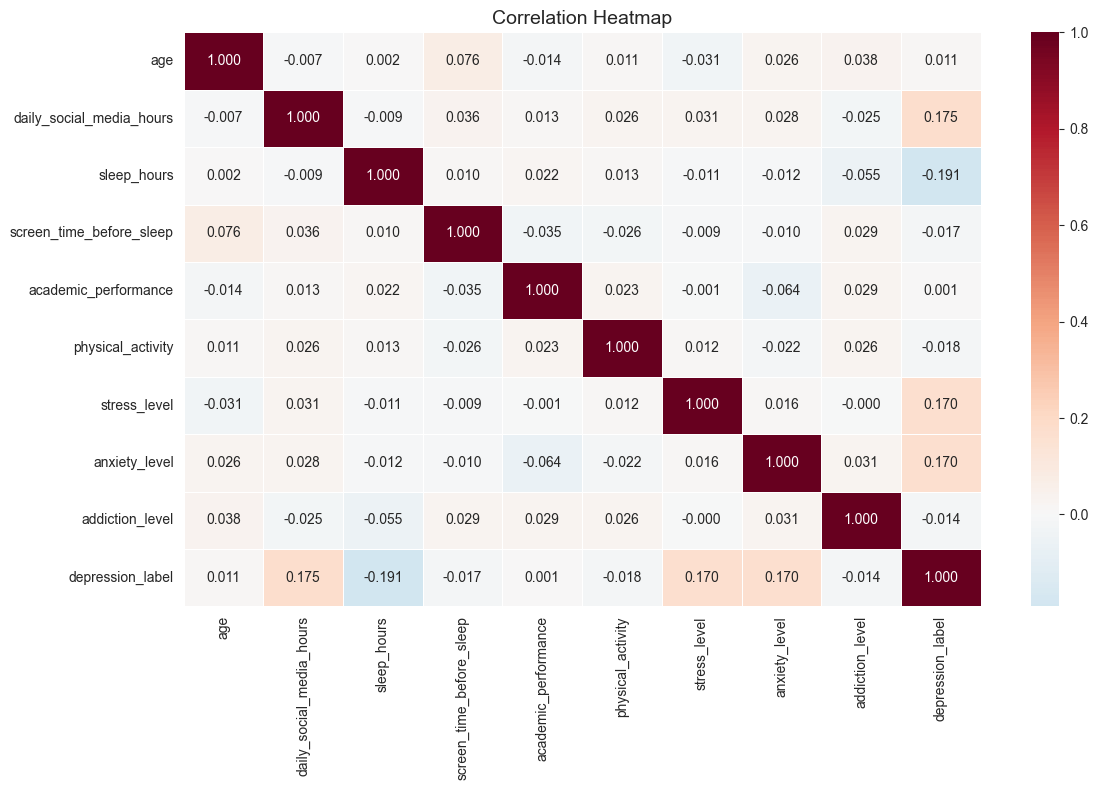

In [13]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level', 
                'anxiety_level', 'addiction_level', 'depression_label']

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

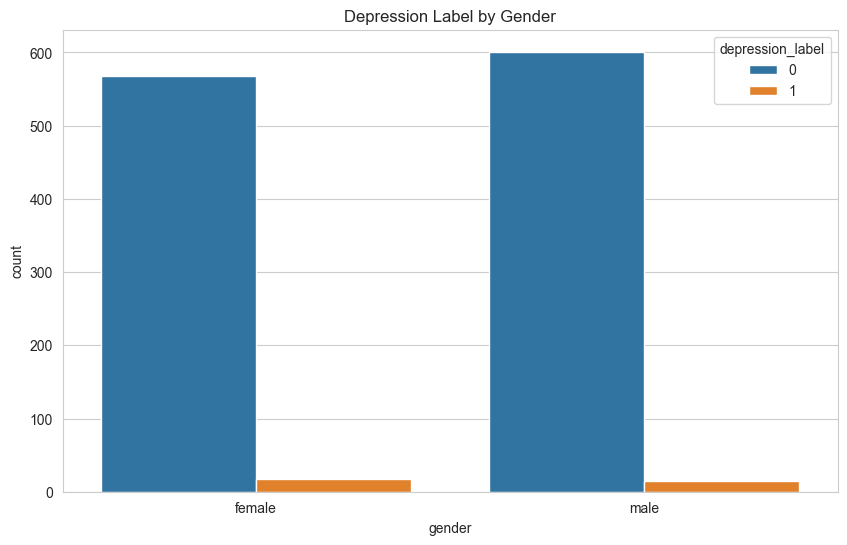

In [17]:
# 2. Depression by Gender
plt.figure()
sns.countplot(data=df, x='gender', hue='depression_label')
plt.title('Depression Label by Gender')
plt.savefig('depression_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\2119229123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='daily_social_media_hours', palette='Blues')


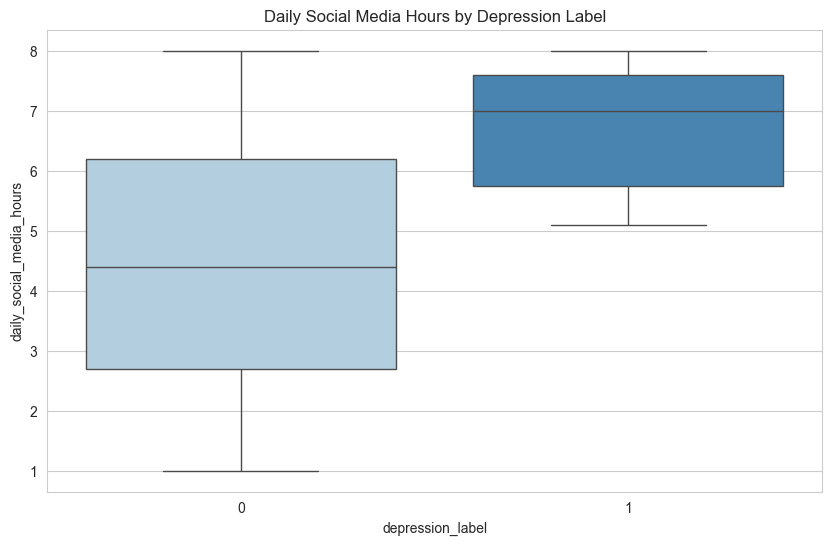

In [18]:
# 3. Daily Social Media Hours by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='daily_social_media_hours', palette='Blues')
plt.title('Daily Social Media Hours by Depression Label')
plt.savefig('social_media_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\2470048798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='sleep_hours', palette='Blues')


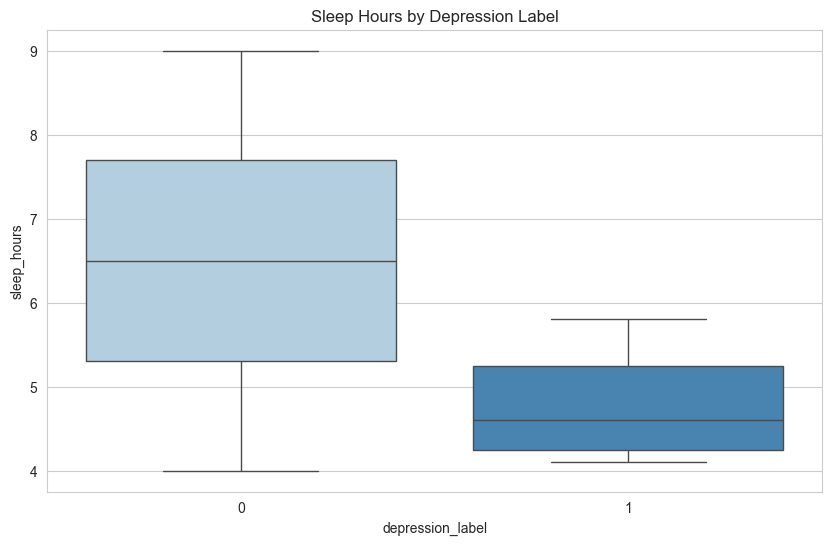

In [19]:
# 4. Sleep Hours by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='sleep_hours', palette='Blues')
plt.title('Sleep Hours by Depression Label')
plt.savefig('sleep_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\1790678963.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='stress_level', palette='Blues')


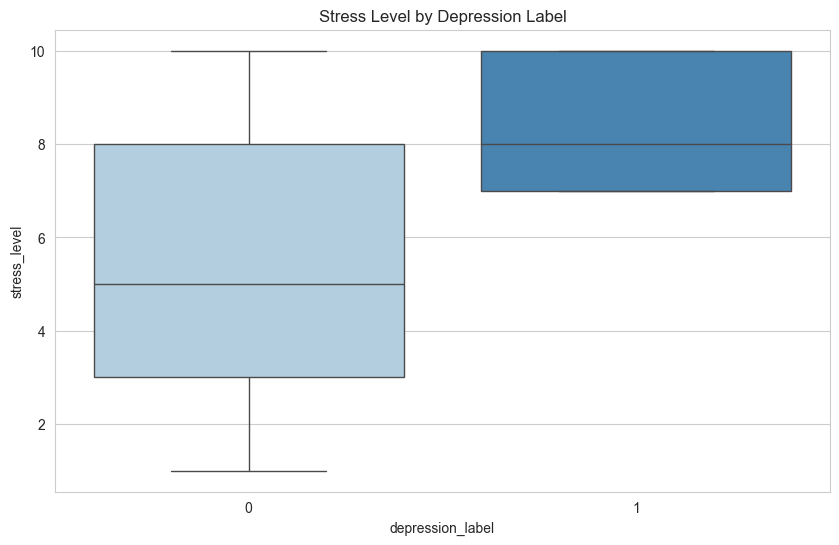

In [20]:
# 5. Stress Level by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='stress_level', palette='Blues')
plt.title('Stress Level by Depression Label')
plt.savefig('stress_level_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\1654630111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='anxiety_level', palette='Blues')


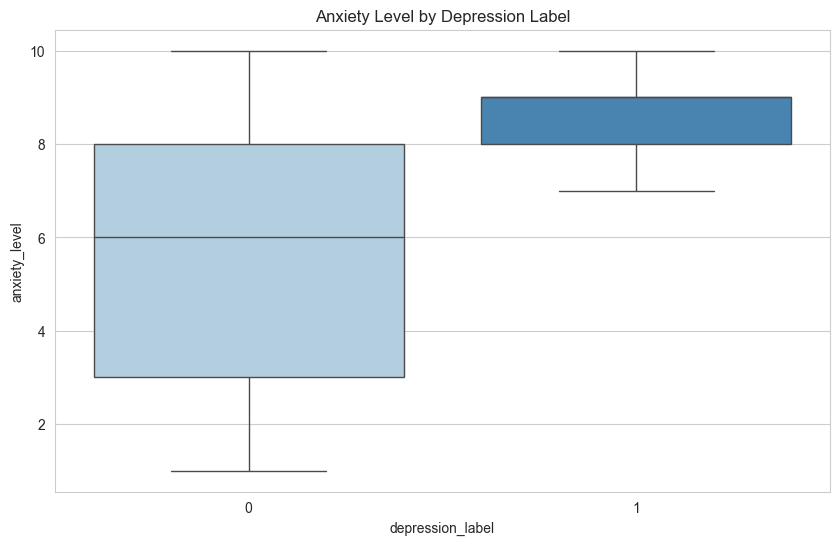

In [21]:
# 6. Anxiety Level by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='anxiety_level', palette='Blues')
plt.title('Anxiety Level by Depression Label')
plt.savefig('anxiety_level_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\1533700107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='addiction_level', palette='Blues')


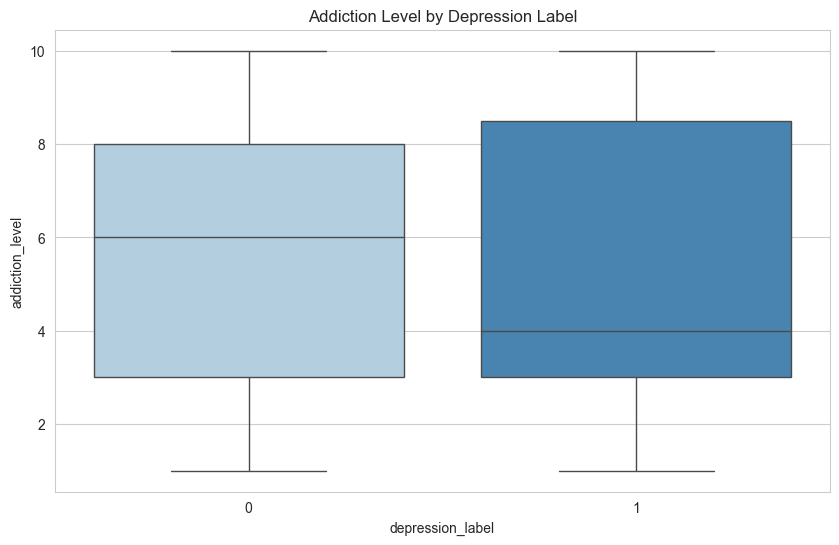

In [22]:
# 7. Addiction Level by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='addiction_level', palette='Blues')
plt.title('Addiction Level by Depression Label')
plt.savefig('addiction_level_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\3115148758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='physical_activity', palette='Blues')


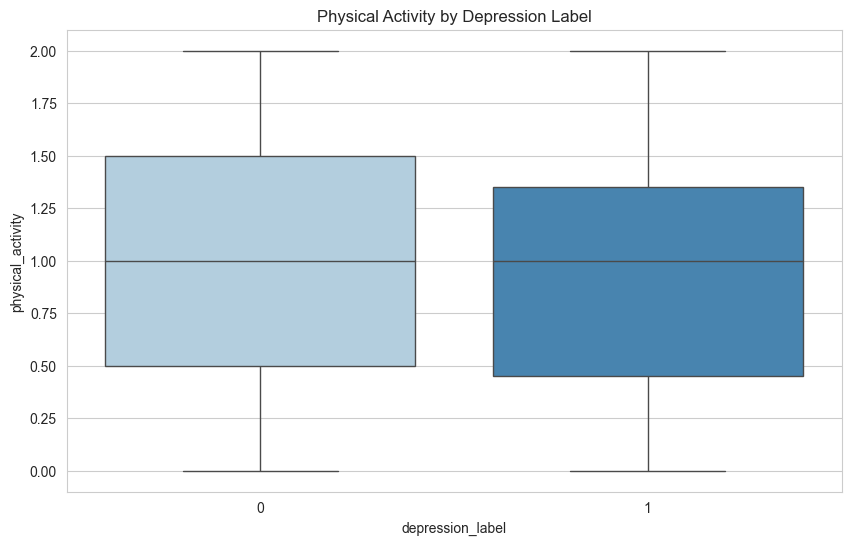

In [23]:
# 8. Physical Activity by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='physical_activity', palette='Blues')
plt.title('Physical Activity by Depression Label')
plt.savefig('physical_activity_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Data Doctor\AppData\Local\Temp\ipykernel_6300\2605615250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='academic_performance', palette='Blues')


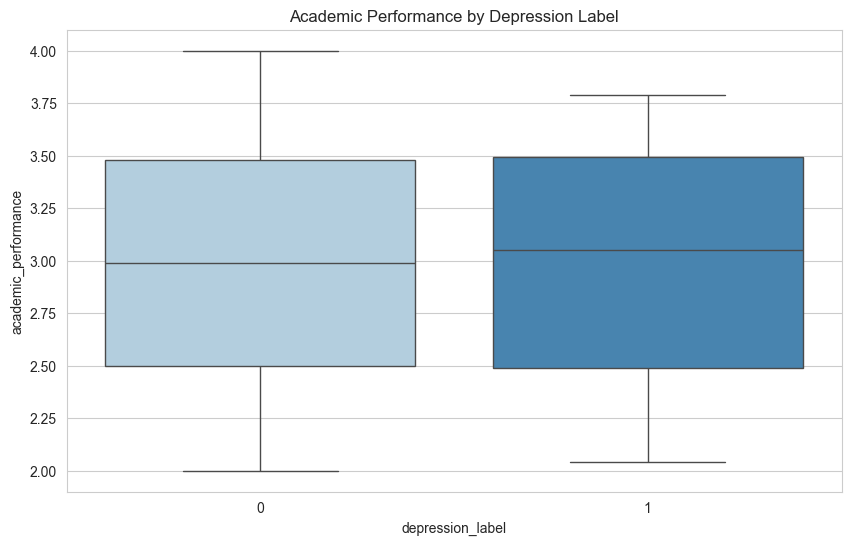

In [24]:
# 9. Academic Performance by Depression
plt.figure()
sns.boxplot(data=df, x='depression_label', y='academic_performance', palette='Blues')
plt.title('Academic Performance by Depression Label')
plt.savefig('academic_performance_by_depression.png', dpi=300, bbox_inches='tight')
plt.show()

- Additional Analysis:

In [25]:
print("\n=== Average Values by Depression Label ===")
print(df.groupby('depression_label')[['daily_social_media_hours', 'sleep_hours', 
                                      'stress_level', 'anxiety_level', 
                                      'addiction_level', 'physical_activity']].mean())


=== Average Values by Depression Label ===
                  daily_social_media_hours  sleep_hours  stress_level  \
depression_label                                                        
0                                 4.478785     6.494183      5.365269   
1                                 6.719355     4.761290      8.483871   

                  anxiety_level  addiction_level  physical_activity  
depression_label                                                     
0                      5.557742         5.571429           1.016168  
1                      8.612903         5.322581           0.951613  


In [26]:
# Platform usage distribution
print("\nPlatform Usage:\n", df['platform_usage'].value_counts())


Platform Usage:
 platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


**Closing Summary**

### Teen Mental Health Analysis – Final Insights

The dataset provides valuable insights into the mental health of **1200 teenagers** (ages 13–19). With **only 31 cases (2.6%)** labeled as having depression, the data is highly imbalanced, reflecting the relative rarity of severe depression in this sample.

### Key Findings:

- **Social Media & Screen Time**: Teens with depression tend to spend **more time on social media** daily. Excessive usage appears linked to higher addiction levels.
  
- **Sleep Quality**: One of the strongest differentiators — depressed teens have **significantly lower sleep hours** on average.

- **Mental Health Indicators**: 
  - Higher **stress**, **anxiety**, and **addiction** levels are clearly associated with depression.
  - Lower **physical activity** and slightly poorer **academic performance** are also observed in the depressed group.

- **Demographics**: Depression cases appear across both genders and all age groups within 13–19, with no single platform (Instagram/TikTok/Both) showing overwhelming dominance.

### Risk Factors Summary:
**Higher Risk** → High daily social media hours, poor sleep, high stress/anxiety/addiction levels, low physical activity.  
**Protective Factors** → Adequate sleep, regular physical activity, better academic performance, and balanced lifestyle.

### Conclusion:
This analysis highlights that **lifestyle factors** — particularly sleep, physical activity, and social media habits — play a significant role in teen mental health. While social media itself isn't the sole cause, excessive use combined with poor sleep and high stress creates a risky combination.

**Recommendation**:  
Early intervention focusing on **improving sleep hygiene**, reducing excessive social media usage, and promoting physical activity could be highly effective in supporting teen mental wellbeing.

Project by: Abhishek M